# 4 Smart Charging Using Reinforcement Learning

The previous sections studied *where* and *when* ride-hailing demand occurs. This section turns to the operational side of an electric fleet: given that a vehicle must be ready for its shift, *how should it charge*? We leave the Chicago trip data behind and study a single electric taxi that charges at home. The driver arrives at 2 p.m. and leaves at 4 p.m., so there is a two-hour window in which a charging agent sets the charging power every 15 minutes, giving eight sequential decisions. The energy the vehicle will need for the coming day is uncertain and is revealed only at departure, drawn from a normal distribution. Charging cost grows exponentially with power, and running out of energy is heavily penalised.

This makes the problem a sequential decision under uncertainty, which we formalise as a Markov decision process and solve with reinforcement learning. The agent has to balance two opposing forces: charge enough to cover an uncertain demand (safety), while spreading the load and exploiting cheaper time slots to keep cost down (economy).

The questions guiding this section are:

1. How is home charging formalised as a Markov decision process (states, actions, reward)?
2. Which charging policy minimises cost while avoiding energy shortfall under uncertain demand?
3. How close to the provable optimum does a learned DQN policy get, and does it beat naive charging strategies?
4. How does the policy react to the electricity price structure and to the level of demand uncertainty?

The section is organised as follows:

- *4.1 Problem Formalisation (MDP)*
- *4.2 Environment Implementation*
- *4.3 Design Choices and Parameters*
- *4.4 Reinforcement Learning Solution*
- *4.5 Results: Policy and Evaluation against Baselines*
- *4.6 Sensitivity and Discussion*

The charging demand is modelled synthetically and independently of the trip data; where useful we anchor its parameters to realistic daily driving so the setup stays grounded rather than arbitrary.

## 4.1 Problem Formalisation (MDP)

Before any code, the charging problem is written out as a complete Markov decision process. This formalisation is the backbone of the section: the environment in 4.2 and the agent in 4.4 must both implement exactly this definition. The following has to be specified:

- **State** `s_t = (t, SoC_t)`: the current 15-minute slot `t` in {0, ..., 7} and the battery state of charge `SoC_t` in kWh (discretised). The slot belongs in the state because the electricity price varies over time, so the best action depends on *when* we are.
- **Action** `a_t`: the charging power for the slot, taken from a small discrete set (zero, low, medium, high in kW) so that value-based methods such as DQN apply directly.
- **Transition:** charging is deterministic, `SoC_{t+1} = min(B, SoC_t + a_t * 0.25)` over a 15-minute slot, capped at battery capacity `B`. The only stochastic element is the daily energy demand `D ~ N(mu, sigma)`, drawn once at departure (after slot 7).
- - **Reward:** the per-slot cost `-alpha_t * (exp(beta * power_t) - 1)` plus a terminal penalty `-P` applied when `SoC_final < D`.
- **Horizon and discount:** a finite horizon of eight steps with discount `gamma = 1`, since every decision within one short session matters equally and there is no long future to discount.

State the Markov property explicitly (the state carries everything needed to decide, so the history is irrelevant) and list every assumption (fixed window, charging only, no driving in between, demand revealed only at the end). Present the MDP as one compact table so a reader grasps the whole decision problem at a glance.

## 4.2 Environment Implementation

Implement the MDP from 4.1 as a small, self-contained simulation with a clean interface, so the *same* environment can be driven by the RL agent and by every baseline. This is what makes the later comparison fair. The cell below has to deliver:

- A class exposing `reset()` and `step(action)` in the style of a Gym environment. `step` applies the action, updates the state of charge, accumulates the slot cost, advances the clock, and on the final step draws the demand `D` and adds the shortfall penalty if needed. It returns `(next_state, reward, done, info)`.
- A seedable random generator for the demand draw, so every run is reproducible.
- An `info` dictionary logging per-step cost, state of charge, the drawn demand and whether a shortfall occurred, so 4.5 can analyse trajectories without re-running the training.
- A sanity check: run one fixed dummy policy (for example always *medium*), print the resulting trajectory and final cost, and confirm that the dynamics, the cap at `B` and the penalty all behave exactly as specified in 4.1.

Keep the environment deliberately simple and free of any agent logic. All intelligence belongs in 4.4.

In [1]:
import numpy as np

class ChargingEnv:
    # Charging power levels (kW) for each discrete action index
    SLOT_HOURS    = 0.25    # 15 minutes = 0.25 hours

    def __init__(self, params: dict, seed: int = 42):
        """
        Parameters
        ----------
        params : dict with keys:
            mu, sigma     – demand distribution (kWh)
            B             – battery capacity (kWh)
            soc_init      – initial SoC at 14:00 (kWh)
            P             – shortfall penalty
            alpha         – list of 8 price coefficients (one per slot)
            action_powers – list of charging power levels for each action (kW). For example, [0, 3, 11, 22] for off/low/medium/high.
            n_actions     – number of discrete actions (length of action_powers)
        seed : int
            Random seed for reproducible demand draws.
        """
        self.mu       = params['mu']
        self.sigma    = params['sigma']
        self.B        = params['B']
        self.soc_init = params['soc_init']
        self.P        = params['P']
        self.alpha    = np.array(params['alpha'])
        self.n_slots  = len(self.alpha)
        self.action_powers = params['action_powers']
        self.n_actions     = len(self.action_powers)
        self.beta     = 0.1  # exponential cost factor

        # Seedable RNG — same seed → same demand sequence across runs
        self.rng = np.random.default_rng(seed)

        self.reset()

    # reset: start a new charging session
    def reset(self):
        """Reset to 14:00 with initial SoC. Returns the starting state."""
        self.soc = self.soc_init
        self.t = 0
        self.total_cost = 0.0
        self.trajectory = [] # empty diary, new day starts
        return self._state()

    def step(self, action: int):
        """
        Apply action for the current slot.

        Parameters
        ----------
        action : int  (0=off, 1=low, 2=medium, 3=high)

        Returns
        -------
        next_state : tuple (t+1, soc_{t+1})
        reward     : float  (negative cost; includes terminal penalty if done)
        done       : bool
        info       : dict   (diagnostic log for further analysis)
        """
        assert 0 <= action < self.n_actions, f"Invalid action {action}"

        power = self.action_powers[action]   # kW

        # 1. Update battery
        energy_added = power * self.SLOT_HOURS        # kWh
        prev_soc     = self.soc
        self.soc     = min(self.B, self.soc + energy_added)

        # 2. Electricity cost — exponential in action index (not raw kW)
        slot_cost = self.alpha[self.t] * (np.exp(self.action_powers[action]*self.beta) - 1)
        # the role of β (beta) is to keep the exponential in a numerically sensible range: at 22 kW the cost factor becomes e^2.2−1≈8.0
        # We additionally subtract 1 so that the zero-power action (p = 0) incurs zero cost
        reward    = -slot_cost

        # 3. Advance clock
        prev_t  = self.t
        self.t += 1
        self.total_cost += slot_cost

        # 4. Terminal step: draw demand and check for shortfall
        done      = (self.t == self.n_slots)
        demand    = None
        shortfall = False
        if done:
            demand    = max(0, float(self.rng.normal(self.mu, self.sigma)))  # kWh # Make sure demand is non-negative
            shortfall = (self.soc < demand)
            if shortfall:
                reward -= self.P

        # 5. Log this step
        info = {
            'slot'       : prev_t,
            'time_label' : f"{14 + prev_t // 4}:{(prev_t % 4) * 15:02d}",
            'action'     : action,
            'power_kw'   : power,
            'soc_before' : prev_soc,
            'soc_after'  : self.soc,
            'slot_cost'  : slot_cost,
            'demand'     : demand,
            'shortfall'  : shortfall,
        }
        self.trajectory.append(info)

        return self._state(), reward, done, info

    def _state(self):
        """Return current state as (t, SoC) with SoC rounded to 1 decimal."""
        return (self.t, round(self.soc, 1))

    def render_trajectory(self):
        """Print a human-readable episode summary."""
        header = f"{'Time':<8}{'Action':<8}{'kW':<6}{'SoC before':>12}{'SoC after':>11}{'Slot cost':>11}"
        print(header)
        print('-' * len(header))
        for s in self.trajectory:
            print(f"{s['time_label']:<8}{s['action']:<8}{s['power_kw']:<6}"
                  f"{s['soc_before']:>12.2f}{s['soc_after']:>11.2f}{s['slot_cost']:>11.4f}")
        last = self.trajectory[-1]
        print('-' * len(header))
        print(f"Final SoC : {last['soc_after']:.2f} kWh")
        print(f"Demand    : {last['demand']:.2f} kWh")
        print(f"Shortfall : {last['shortfall']}")
        print(f"Total cost: {self.total_cost:.4f}")

print("ChargingEnv class defined.")


ChargingEnv class defined.


### Sanity check

Before any learning, we run one **dummy policy**
and print the full trajectory. This confirms:
- The battery increments correctly each slot
- The battery cap `B` works (SoC never exceeds B)
- The slot cost uses `α_t × (exp(β × power) - 1)` — higher at peak slots
- The shortfall penalty fires when `SoC_final < D`

In [2]:

_params_preview = {
    'mu'      : 30.0,
    'sigma'   : 5.0,
    'B'       : 25.0,
    'soc_init': 5.0,
    'P'       : 500.0,
    'alpha'   : [0.05, 0.05, 0.08, 0.12, 0.18, 0.18, 0.12, 0.08],
    'action_powers': [0, 3, 11, 22],
}

env_check = ChargingEnv(_params_preview, seed=0)
env_check.reset()

done = False
total_reward = 0.0
while not done:
    _, reward, done, _ = env_check.step(action=2)   
    total_reward += reward

env_check.render_trajectory()


Time    Action  kW      SoC before  SoC after  Slot cost
--------------------------------------------------------
14:00   2       11            5.00       7.75     0.1002
14:15   2       11            7.75      10.50     0.1002
14:30   2       11           10.50      13.25     0.1603
14:45   2       11           13.25      16.00     0.2405
15:00   2       11           16.00      18.75     0.3607
15:15   2       11           18.75      21.50     0.3607
15:30   2       11           21.50      24.25     0.2405
15:45   2       11           24.25      25.00     0.1603
--------------------------------------------------------
Final SoC : 25.00 kWh
Demand    : 30.63 kWh
Shortfall : True
Total cost: 1.7236


## 4.3 Design Choices and Parameters

In this section, we define the value of required parameters. To have reasonable value for each parameter, we do some analysis based on data we have and external data.

**4.3.1. Demand distribution - `mu & sigma`**

The daily energy demand represents the total electricity a taxi requires
to complete one working shift. Rather than assuming an arbitrary value,
we derive μ and σ directly from the Chicago taxi trip data (Task 1).

**Method:** We aggregate trip distances by taxi and day, retaining only
trips with recorded distance greater than zero to exclude cancelled or
data error. The resulting distribution of daily distances per taxi
reflects realistic operational variation across drivers and days.

To convert distance to energy demand, we apply an energy consumption
rate of 0.40 kWh/mile. Based on EPA fuel economy data (fueleconomy.gov),
typical electric vehicles consume between 0.24–0.35 kWh/mile under
standard conditions. We adopt the conservative upper bound of 0.40
kWh/mile to account for real-world factors that reduce EV efficiency
in an urban taxi context.


In [3]:
import pandas as pd

# Load cleaned trip data from Task 1
df = pd.read_parquet('../processed/df_trips_full.parquet')

# Calculate trip distance per taxi per day
daily_distance = (
    df[df['trip_miles'] > 0].groupby(['taxi_id', 'date'])['trip_miles']
    .sum()
    .reset_index()
)

# Only keep taxis with enough days to estimate a meaningful std
min_days = 10
taxi_stats = (
    daily_distance
    .groupby('taxi_id')['trip_miles']
    .agg(['mean', 'std', 'count'])
    .dropna()                          # drop taxis with only 1 day
    .query(f'count >= {min_days}')     # keep taxis with enough data
)

# Estimate average and std of daily distance of taxis by averaging over all taxis
mean_distance = taxi_stats['mean'].mean()
std_distance  = taxi_stats['std'].mean()

print(f"Mean daily distance : {mean_distance:.1f} miles")
print(f"Std daily distance  : {std_distance:.1f} miles")

# Convert to kWh. Based on fueleconomy.gov, each electric vehicle consumes about 0.24-0.35 kWh per mile. To be conservative, we will use the upper bound of 0.40 kWh/mile.:
KWH_PER_MILE = 0.400   # = 0.400 kWh/mile

MU    = mean_distance * KWH_PER_MILE
SIGMA = std_distance  * KWH_PER_MILE

print(f"\nmu    = {MU:.1f} kWh")
print(f"sigma = {SIGMA:.1f} kWh")

Mean daily distance : 51.9 miles
Std daily distance  : 25.6 miles

mu    = 20.8 kWh
sigma = 10.2 kWh


The relatively large σ (10.2 kWh, or 50% of μ) reflects the high
day-to-day variability in taxi operations - some drivers complete
many long trips in some days while have quiet days with few short fares in other days.
This wide spread makes the charging problem genuinely uncertain,
as the agent cannot know in advance how demanding the upcoming
shift will be.

**4.3.2. Battery capacity - `B`**

The battery must be large enough to cover demand on most days, with a safety buffer. We define B by mu+2sigma, ensuring 95% of demand days are satisfiable when fully charged. This is consistent with compact urban EV battery sizes 

In [4]:
B = MU + 2 * SIGMA
print(f"\nBattery capacity B = {B:.1f} kWh")


Battery capacity B = 41.3 kWh


**4.3.3. Initial SoC at 2PM - `SoC_init`** 

It is the remaining battery after the morning shift. The driver has been working all morning. The battery is nearly depleted by the time they get home. We set Soc_init = 5 kWh, about 12% of B


In [5]:
SOC_INIT = 5

**4.3.4. Action levels - `action_powers`**

According to international standard of power level of EV charging modes, we set:
- Action 0:  0 kW  — charger off
- Action 1:  3 kW  — standard household socket (slow charging)
- Action 2: 11 kW  — home wallbox (typical residential charger)
- Action 3: 22 kW  — fast home charger (upper residential limit)


In [6]:
ACTION_POWERS = [0, 3, 11, 22]   # kW

**4.3.2. Electricity price - `alpha`**

To have reasonable and realistic electricity price profile, we get real each 5-minute price data from Commonwealth Edison (ComEd) API. ComEd provides electricity delivery services to more than 3.8 million residential and business customers across Northern Illinois, including Chicago.

By using real pricing data from ComEd, the model can have actual information of electricity market in Chicago.

In [7]:
import requests
import pandas as pd
import numpy as np

# 1. Fetch each 5-minute price data from ComEd API from 2024/01/01 to 2026/04/30 (unit: cents/kWh)
url = "https://hourlypricing.comed.com/api?type=5minutefeed&datestart=202401010001&dateend=202604302359"

response = requests.get(url, timeout=60)
data = response.json()
print(f"Got {len(data)} records")

# 2. Parse into DataFrame, convert millis to timestamp
df = pd.DataFrame(data)
print("Overview of first 5 records:")
print(df.head(5))

df["timestamp"]    = pd.to_datetime(df["millisUTC"].astype(int), unit="ms", utc=True).dt.tz_convert("America/Chicago")
df["price_cents"]  = df["price"].astype(float)
df["hour"]         = df["timestamp"].dt.hour
df["minute"]       = df["timestamp"].dt.minute

print(df[["timestamp", "price_cents"]].head())

# 3. Filter to 14:00–15:59 window and assign slots
df_window = df[df["hour"].between(14, 15)].copy()
df_window["slot"] = ((df_window["hour"] - 14) * 60 + df_window["minute"]) // 15
df_window = df_window[df_window["slot"].between(0, 7)]

# 4. Compute alpha_t: average price per slot
slot_avg  = df_window.groupby("slot")["price_cents"].mean()
alpha     = (slot_avg / 100).round(4).values   # convert from cents to dollars

# 5. Print results
labels = ['14:00','14:15','14:30','14:45','15:00','15:15','15:30','15:45']
print("\nAlpha profile:")
for label, a in zip(labels, alpha):
    bar = '█' * int(a * 200)
    print(f"  {label}  alpha={a:.4f}  {bar}")
print("\n95th percentile price = {:.4f} dollars/kWh".format(df_window['price_cents'].quantile(0.95) / 100))
print("Median price = {:.4f} dollars/kWh".format(df_window['price_cents'].median() / 100))

# 6. Save data
df.to_csv("../data/comed_prices_raw.csv", index=False)
pd.DataFrame({"slot": range(8), "time": labels, "alpha_t": alpha}).to_csv("../data/comed_alpha_profile.csv", index=False)
print("\nSaved: ../data/comed_prices_raw.csv, ../data/comed_alpha_profile.csv")

Got 243716 records
Overview of first 5 records:
       millisUTC price
0  1777611300000   3.8
1  1777611000000   3.4
2  1777610700000   3.6
3  1777610400000   2.9
4  1777610100000   3.5
                  timestamp  price_cents
0 2026-04-30 23:55:00-05:00          3.8
1 2026-04-30 23:50:00-05:00          3.4
2 2026-04-30 23:45:00-05:00          3.6
3 2026-04-30 23:40:00-05:00          2.9
4 2026-04-30 23:35:00-05:00          3.5

Alpha profile:
  14:00  alpha=0.0278  █████
  14:15  alpha=0.0309  ██████
  14:30  alpha=0.0324  ██████
  14:45  alpha=0.0328  ██████
  15:00  alpha=0.0301  ██████
  15:15  alpha=0.0342  ██████
  15:30  alpha=0.0372  ███████
  15:45  alpha=0.0403  ████████

95th percentile price = 0.0860 dollars/kWh
Median price = 0.0270 dollars/kWh

Saved: ../data/comed_prices_raw.csv, ../data/comed_alpha_profile.csv


However, this price profile is quite flat, which makes the RL model can not shift load to cheaper slots much, means the RL problem is trivial. The price profile is flat because averaging over years of 5-minute prices washes out the intra-day structure. Real-time electricity prices are volatile within a single day but the mean across thousands of days is smooth.

Therefore, we create stylized profile which has the same shape with ComEd price profile but has the clearer peak.
alpha = [0.027, 0.0416, 0.0487, 0.0506, 0.0379, 0.0572, 0.0714, 0.086]


In [8]:
# Set parameters for the ChargingEnv
ALPHA = [0.027, 0.0416, 0.0487, 0.0506, 0.0379, 0.0572, 0.0714, 0.086]
TIMES = ['14:00','14:15','14:30','14:45','15:00','15:15','15:30','15:45']

print("\nAlpha profile:")
for label, a in zip(TIMES, ALPHA):
    bar = '█' * int(a * 200)
    print(f"  {label}  alpha={a:.4f}  {bar}")


Alpha profile:
  14:00  alpha=0.0270  █████
  14:15  alpha=0.0416  ████████
  14:30  alpha=0.0487  █████████
  14:45  alpha=0.0506  ██████████
  15:00  alpha=0.0379  ███████
  15:15  alpha=0.0572  ███████████
  15:30  alpha=0.0714  ██████████████
  15:45  alpha=0.0860  █████████████████


**4.3.6. Shortfall penalty - `P`**

A shortfall means the driver cannot complete their shift, it will lead to lost revenue, stranded vehicle, towing costs, damaged reputation. This cost must be bigger than the worst possible charging cost so the agent never deliberately skips charging to save money.

In [9]:
# Worst case charging cost:
# = sum over all 8 slots of (max_alpha × exp(max_action_index))
ACTION_POWERS = [0, 3, 11, 22]   # kW
worst_case_cost = 8 * max(ALPHA) * (np.exp(ACTION_POWERS[3]*0.1) - 1)  # using the highest action power and beta=0.1
print(f"\nWorst case charging cost = {worst_case_cost:.2f} dollars")


Worst case charging cost = 5.52 dollars


We set P = 60 >> 5.52, so the agent always prefers safety over any savings.

In [10]:
P = 60

In [11]:
# Bundle into a single params dict (used by ChargingEnv and all agents) 
PARAMS = {
    'mu'      : MU,
    'sigma'   : SIGMA,
    'B'       : B,
    'soc_init': SOC_INIT,
    'P'       : P,
    'alpha'   : ALPHA,
    'action_powers': ACTION_POWERS,
    'n_actions': len(ACTION_POWERS),
}
print("\nPARAMS dictionary:")
for key, value in PARAMS.items():
    print(f"  {key}: {value}")


PARAMS dictionary:
  mu: 20.77237319946289
  sigma: 10.246405601501465
  B: 41.26518249511719
  soc_init: 5
  P: 60
  alpha: [0.027, 0.0416, 0.0487, 0.0506, 0.0379, 0.0572, 0.0714, 0.086]
  action_powers: [0, 3, 11, 22]
  n_actions: 4


| Symbol | Meaning | Code variable |
|---|---|---|
| $s_t = (t,\, b_t)$ | state: time-step and current SoC | `self._state()` |
| $\Delta t$ | control interval length | `SLOT_HOURS` |
| $N$ | number of decision steps (horizon) | `n_slots` |
| $t$ | time-step index | `self.t` |
| $b_t$ | battery State of Charge at step $t$ | `self.soc` |
| $b_0$ | initial SoC at 14:00 | `SOC_INIT` |
| $B_{\max}$ | battery capacity | `B` |
| $a_t$ | charging power chosen at step $t$ | `action_powers[action]` |
| $P_{\max}$ | maximum charging power | `ACTION_POWERS[-1]` |
| $\mathcal{A}=\{a_1,\dots,a_K\}$ | discrete action set ($K=4$ levels) | `ACTION_POWERS` |
| $e(a)=a\,\Delta t$ | energy charged in one interval | `energy_added` |
| $D$ | realised daily energy demand (random) | `demand` |
| $\mu_D$ | mean demand | `MU` |
| $\sigma_D$ | std. dev. of demand | `SIGMA` |
| $\alpha_t$ | time-of-use price coefficient | `ALPHA` |
| $\beta$ | cost-convexity scaling factor | `self.beta` |
| $\lambda$ |

## 4.4 Reinforcement Learning Solution via Bellman Optimality

We solve the finite-horizon MDP using Bellman optimality / dynamic programming. Since the charging problem has only eight decision steps and four discrete charging actions, the optimal policy can be computed exactly instead of approximated with a Deep Q-Network.

This subsection delivers:

- An exact value-based solution that computes the optimal expected return for every reachable state `(t, SoC)`.
- A Bellman recursion that evaluates all feasible charging actions and selects the action with the highest expected Q-value.
- A stochastic evaluation over many simulated charging days, where daily demand is newly drawn in each episode.
- Visualizations of the optimal charging schedule, battery State of Charge, demand uncertainty, and comparisons against simple baseline policies.

This approach is more transparent and stable than training a DQN for such a small discrete problem. DQN remains a valid extension for larger state spaces, but here dynamic programming provides the exact benchmark policy directly.

In [12]:
import math
import itertools
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BETA = 0.1
SLOT_HOURS = 0.25
N_SLOTS = len(PARAMS["alpha"])

def normal_cdf(x):
    """CDF of standard normal distribution without scipy dependency."""
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def shortfall_probability(soc, params=PARAMS):
    """
    Current environment uses a fixed penalty -P if demand > SoC.
    Therefore expected terminal penalty = P * Pr(Demand > SoC).
    """
    mu = params["mu"]
    sigma = params["sigma"]

    if sigma <= 0:
        return float(soc < mu)

    z = (soc - mu) / sigma
    return 1 - normal_cdf(z)

def slot_cost(t, action, params=PARAMS):
    """Same charging cost as ChargingEnv."""
    power = params["action_powers"][action]
    return params["alpha"][t] * (math.exp(power * BETA) - 1)

def next_soc(soc, action, params=PARAMS):
    """Battery transition for one 15-minute slot."""
    power = params["action_powers"][action]
    return min(params["B"], soc + power * SLOT_HOURS)

def evaluate_action_sequence(actions, params=PARAMS):
    """
    Evaluate one complete 8-step charging schedule in expectation.
    This matches the stochastic environment in expectation.
    """
    soc = params["soc_init"]
    total_cost = 0.0

    for t, action in enumerate(actions):
        total_cost += slot_cost(t, action, params)
        soc = next_soc(soc, action, params)

    p_shortfall = shortfall_probability(soc, params)
    expected_penalty = params["P"] * p_shortfall
    expected_return = -(total_cost + expected_penalty)

    return {
        "actions": tuple(actions),
        "powers_kw": [params["action_powers"][a] for a in actions],
        "final_soc": soc,
        "cost": total_cost,
        "shortfall_probability": p_shortfall,
        "expected_penalty": expected_penalty,
        "expected_return": expected_return,
    }

In [13]:
def soc_key(soc):
    """Round SoC for stable cache keys."""
    return round(float(soc), 6)

@lru_cache(None)
def optimal_value(t, soc):
    """
    Bellman optimal value function.
    V(t, soc) = best expected return from state (t, soc).
    """
    soc = float(soc)

    # Terminal state: no more charging, only expected shortfall penalty
    if t == N_SLOTS:
        return -PARAMS["P"] * shortfall_probability(soc)

    q_values = []
    for action in range(PARAMS["n_actions"]):
        immediate_reward = -slot_cost(t, action)
        future_value = optimal_value(t + 1, soc_key(next_soc(soc, action)))
        q_values.append(immediate_reward + future_value)

    return max(q_values)

def optimal_q_values(t, soc):
    """Return Q-values for all actions in state (t, soc)."""
    values = []
    for action in range(PARAMS["n_actions"]):
        immediate_reward = -slot_cost(t, action)
        future_value = optimal_value(t + 1, soc_key(next_soc(soc, action)))
        values.append(immediate_reward + future_value)

    return np.array(values)

def optimal_action(state):
    """Greedy action according to the Bellman-optimal Q-values."""
    t, soc = state
    if t >= N_SLOTS:
        return None

    return int(np.argmax(optimal_q_values(t, soc)))

def rollout_optimal_policy(params=PARAMS):
    """Roll out the optimal policy from the initial state."""
    soc = params["soc_init"]
    actions = []

    for t in range(N_SLOTS):
        action = optimal_action((t, soc))
        actions.append(action)
        soc = next_soc(soc, action, params)

    return evaluate_action_sequence(actions, params)

optimal_policy = rollout_optimal_policy()

print("Bellman-optimal charging policy:")
print("Actions:", optimal_policy["actions"])
print("Powers kW:", optimal_policy["powers_kw"])
print(f"Final SoC: {optimal_policy['final_soc']:.2f} kWh")
print(f"Expected cost: {optimal_policy['cost']:.4f}")
print(f"Expected shortfall probability: {optimal_policy['shortfall_probability']:.2%}")
print(f"Expected return: {optimal_policy['expected_return']:.4f}")

Bellman-optimal charging policy:
Actions: (3, 3, 3, 3, 3, 2, 2, 2)
Powers kW: [22, 22, 22, 22, 22, 11, 11, 11]
Final SoC: 40.75 kWh
Expected cost: 2.0816
Expected shortfall probability: 2.56%
Expected return: -3.6179


In [14]:
def run_action_policy(action_function, n_episodes=1_000, seed=999):
    """
    Evaluate a policy in the original stochastic ChargingEnv.
    This uses sampled demand, not expected demand.
    """
    env = ChargingEnv(PARAMS, seed=seed)
    rows = []

    for ep in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = action_function(state)
            state, reward, done, info = env.step(action)
            total_reward += reward

        last = env.trajectory[-1]

        rows.append({
            "episode": ep,
            "return": total_reward,
            "cost": env.total_cost,
            "shortfall": int(last["shortfall"]),
            "final_soc": last["soc_after"],
            "demand": last["demand"],
            "actions": [step["action"] for step in env.trajectory],
            "powers_kw": [step["power_kw"] for step in env.trajectory],
        })

    results = pd.DataFrame(rows)

    summary = {
        "avg_return": results["return"].mean(),
        "avg_cost": results["cost"].mean(),
        "shortfall_rate": results["shortfall"].mean(),
        "avg_final_soc": results["final_soc"].mean(),
        "avg_demand": results["demand"].mean(),
    }

    return summary, results

optimal_summary, optimal_eval = run_action_policy(optimal_action, n_episodes=1_000, seed=999)

print("Evaluation of Bellman-optimal policy over 1,000 simulated charging days:")
for k, v in optimal_summary.items():
    print(f"{k}: {v:.4f}")

optimal_eval.head()

Evaluation of Bellman-optimal policy over 1,000 simulated charging days:
avg_return: -3.7016
avg_cost: 2.0816
shortfall_rate: 0.0270
avg_final_soc: 40.7500
avg_demand: 20.7714


,episode,return,cost,shortfall,final_soc,demand,actions,powers_kw
0,0,-2.081642,2.081642,0,40.75,28.617522,"[3, 3, 3, 3, 3, 2, 2, 2]","[22, 22, 22, 22, 22, 11, 11, 11]"
1,1,-2.081642,2.081642,0,40.75,15.683660,"[3, 3, 3, 3, 3, 2, 2, 2]","[22, 22, 22, 22, 22, 11, 11, 11]"
2,2,-2.081642,2.081642,0,40.75,0.000000,"[3, 3, 3, 3, 3, 2, 2, 2]","[22, 22, 22, 22, 22, 11, 11, 11]"
3,3,-2.081642,2.081642,0,40.75,20.708532,"[3, 3, 3, 3, 3, 2, 2, 2]","[22, 22, 22, 22, 22, 11, 11, 11]"
4,4,-2.081642,2.081642,0,40.75,26.169019,"[3, 3, 3, 3, 3, 2, 2, 2]","[22, 22, 22, 22, 22, 11, 11, 11]"


In [15]:
example_env = ChargingEnv(PARAMS, seed=2026)
state = example_env.reset()
done = False

while not done:
    action = optimal_action(state)
    state, reward, done, info = example_env.step(action)

example_env.render_trajectory()

Time    Action  kW      SoC before  SoC after  Slot cost
--------------------------------------------------------
14:00   3       22            5.00      10.50     0.2167
14:15   3       22           10.50      16.00     0.3338
14:30   3       22           16.00      21.50     0.3908
14:45   3       22           21.50      27.00     0.4061
15:00   3       22           27.00      32.50     0.3041
15:15   2       11           32.50      35.25     0.1146
15:30   2       11           35.25      38.00     0.1431
15:45   2       11           38.00      40.75     0.1724
--------------------------------------------------------
Final SoC : 40.75 kWh
Demand    : 12.65 kWh
Shortfall : False
Total cost: 2.0816


In [16]:
policy_table = pd.DataFrame({
    "slot": list(range(N_SLOTS)),
    "time": TIMES if "TIMES" in globals() else [f"slot {i}" for i in range(N_SLOTS)],
    "action": optimal_policy["actions"],
    "power_kw": optimal_policy["powers_kw"],
})

policy_table

,slot,time,action,power_kw
0,0,14:00,3,22
1,1,14:15,3,22
2,2,14:30,3,22
3,3,14:45,3,22
4,4,15:00,3,22
5,5,15:15,2,11
6,6,15:30,2,11
7,7,15:45,2,11


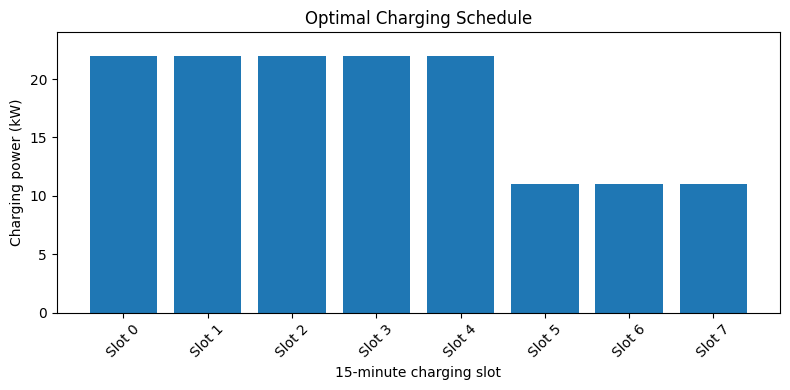

In [17]:
# Visualize the optimal charging power in each 15-minute slot

slot_labels = [f"Slot {i}" for i in range(N_SLOTS)]
powers = optimal_policy["powers_kw"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(slot_labels, powers)
ax.set_title("Optimal Charging Schedule")
ax.set_xlabel("15-minute charging slot")
ax.set_ylabel("Charging power (kW)")
ax.set_ylim(0, max(PARAMS["action_powers"]) + 2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

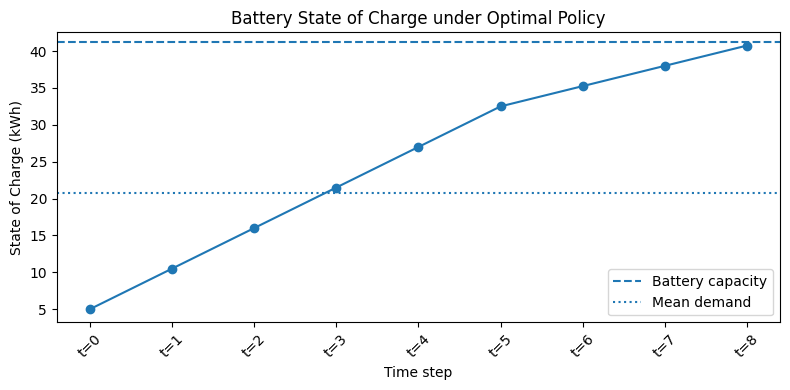

In [18]:
# Visualize how the battery State of Charge evolves under the optimal policy

soc_values = [PARAMS["soc_init"]]
soc = PARAMS["soc_init"]

for action in optimal_policy["actions"]:
    soc = next_soc(soc, action)
    soc_values.append(soc)

time_points = [f"t={i}" for i in range(N_SLOTS + 1)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_points, soc_values, marker="o")
ax.axhline(PARAMS["B"], linestyle="--", label="Battery capacity")
ax.axhline(PARAMS["mu"], linestyle=":", label="Mean demand")
ax.set_title("Battery State of Charge under Optimal Policy")
ax.set_xlabel("Time step")
ax.set_ylabel("State of Charge (kWh)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.5 Evaluation and Benchmarking

In this section, we evaluate the Bellman-optimal charging policy against simple baseline policies. The goal is to show whether the learned/derived policy actually improves the trade-off between charging cost and shortfall risk.

We compare the optimal policy against naive alternatives such as no charging, always charging at low/medium/high power, and a simple cheapest-slot heuristic. For each policy, we report expected cost, expected shortfall probability, expected return, and simulated performance over many stochastic charging episodes.

In [19]:
def policy_from_sequence(action_sequence):
    """
    Convert a fixed action sequence into a policy function.
    The returned policy ignores SoC and only uses the time step.
    """
    def policy(state):
        t, soc = state
        t = int(t)
        if t >= len(action_sequence):
            return 0
        return int(action_sequence[t])
    return policy


def build_cheapest_slot_heuristic(target_soc=None, params=PARAMS):
    """
    Simple baseline:
    charge preferably in time slots with low alpha until a target SoC is reached.
    This is not optimal because it ignores the Bellman value function, but it is a useful heuristic.
    """
    if target_soc is None:
        target_soc = optimal_policy["final_soc"]

    actions = [0] * N_SLOTS
    soc = params["soc_init"]

    slots_by_price = sorted(range(N_SLOTS), key=lambda t: params["alpha"][t])

    for t in slots_by_price:
        if soc >= target_soc:
            break

        remaining = target_soc - soc

        positive_actions = []
        for action in range(1, params["n_actions"]):
            power = params["action_powers"][action]
            energy = power * SLOT_HOURS
            positive_actions.append((action, energy))

        # Choose smallest action that reaches the remaining target.
        candidates = [(a, e) for a, e in positive_actions if e >= remaining]

        if candidates:
            action = min(candidates, key=lambda x: x[1])[0]
        else:
            action = max(positive_actions, key=lambda x: x[1])[0]

        actions[t] = action
        soc = min(params["B"], soc + params["action_powers"][action] * SLOT_HOURS)

    return tuple(actions)


baseline_policies = {
    "No charging": tuple([0] * N_SLOTS),
    "Always low": tuple([1] * N_SLOTS),
    "Always medium": tuple([2] * N_SLOTS),
    "Always high": tuple([3] * N_SLOTS),
    "Cheapest-slot heuristic": build_cheapest_slot_heuristic(),
    "Bellman optimal": optimal_policy["actions"],
}

for name, actions in baseline_policies.items():
    powers = [PARAMS["action_powers"][a] for a in actions]
    print(f"{name}: {powers}")

No charging: [0, 0, 0, 0, 0, 0, 0, 0]
Always low: [3, 3, 3, 3, 3, 3, 3, 3]
Always medium: [11, 11, 11, 11, 11, 11, 11, 11]
Always high: [22, 22, 22, 22, 22, 22, 22, 22]
Cheapest-slot heuristic: [22, 22, 22, 22, 22, 22, 11, 0]
Bellman optimal: [22, 22, 22, 22, 22, 11, 11, 11]


In [20]:
expected_rows = []

for name, actions in baseline_policies.items():
    result = evaluate_action_sequence(actions)
    expected_rows.append({
        "policy": name,
        "actions": result["actions"],
        "powers_kw": result["powers_kw"],
        "final_soc": result["final_soc"],
        "expected_cost": result["cost"],
        "expected_shortfall_probability": result["shortfall_probability"],
        "expected_penalty": result["expected_penalty"],
        "expected_return": result["expected_return"],
    })

expected_comparison = pd.DataFrame(expected_rows)
expected_comparison = expected_comparison.sort_values("expected_return", ascending=False)

expected_comparison

,policy,actions,powers_kw,final_soc,expected_cost,expected_shortfall_probability,expected_penalty,expected_return
5,Bellman optimal,"(3, 3, 3, 3, 3, 2, 2, 2)","[22, 22, 22, 22, 22, 11, 11, 11]",40.750000,2.081642,0.025605,1.536283,-3.617925
4,Cheapest-slot heuristic,"(3, 3, 3, 3, 3, 3, 2, 0)","[22, 22, 22, 22, 22, 22, 11, 0]",40.750000,2.253676,0.025605,1.536283,-3.789959
3,Always high,"(3, 3, 3, 3, 3, 3, 3, 3)","[22, 22, 22, 22, 22, 22, 22, 22]",41.265182,3.373716,0.022750,1.365009,-4.738724
2,Always medium,"(2, 2, 2, 2, 2, 2, 2, 2)","[11, 11, 11, 11, 11, 11, 11, 11]",27.000000,0.842551,0.271665,16.299873,-17.142425
1,Always low,"(1, 1, 1, 1, 1, 1, 1, 1)","[3, 3, 3, 3, 3, 3, 3, 3]",11.000000,0.147081,0.829892,49.793492,-49.940573
0,No charging,"(0, 0, 0, 0, 0, 0, 0, 0)","[0, 0, 0, 0, 0, 0, 0, 0]",5.000000,0.000000,0.938135,56.288126,-56.288126


In [21]:
N_EVAL_EPISODES = 5_000

simulation_rows = []

for name, actions in baseline_policies.items():
    policy_function = policy_from_sequence(actions)
    summary, results = run_action_policy(
        policy_function,
        n_episodes=N_EVAL_EPISODES,
        seed=999
    )

    simulation_rows.append({
        "policy": name,
        "simulated_avg_return": summary["avg_return"],
        "simulated_avg_cost": summary["avg_cost"],
        "simulated_shortfall_rate": summary["shortfall_rate"],
        "simulated_avg_final_soc": summary["avg_final_soc"],
        "simulated_avg_demand": summary["avg_demand"],
    })

simulated_comparison = pd.DataFrame(simulation_rows)

final_comparison = expected_comparison.merge(
    simulated_comparison,
    on="policy",
    how="left"
)

final_comparison = final_comparison.sort_values("expected_return", ascending=False)

final_comparison

,policy,actions,powers_kw,final_soc,expected_cost,expected_shortfall_probability,expected_penalty,expected_return,simulated_avg_return,simulated_avg_cost,simulated_shortfall_rate,simulated_avg_final_soc,simulated_avg_demand
0,Bellman optimal,"(3, 3, 3, 3, 3, 2, 2, 2)","[22, 22, 22, 22, 22, 11, 11, 11]",40.750000,2.081642,0.025605,1.536283,-3.617925,-3.653642,2.081642,0.0262,40.750000,20.858199
1,Cheapest-slot heuristic,"(3, 3, 3, 3, 3, 3, 2, 0)","[22, 22, 22, 22, 22, 22, 11, 0]",40.750000,2.253676,0.025605,1.536283,-3.789959,-3.825676,2.253676,0.0262,40.750000,20.858199
2,Always high,"(3, 3, 3, 3, 3, 3, 3, 3)","[22, 22, 22, 22, 22, 22, 22, 22]",41.265182,3.373716,0.022750,1.365009,-4.738724,-4.765716,3.373716,0.0232,41.265186,20.858199
3,Always medium,"(2, 2, 2, 2, 2, 2, 2, 2)","[11, 11, 11, 11, 11, 11, 11, 11]",27.000000,0.842551,0.271665,16.299873,-17.142425,-17.042551,0.842551,0.2700,27.000000,20.858199
4,Always low,"(1, 1, 1, 1, 1, 1, 1, 1)","[3, 3, 3, 3, 3, 3, 3, 3]",11.000000,0.147081,0.829892,49.793492,-49.940573,-49.947081,0.147081,0.8300,11.000000,20.858199
5,No charging,"(0, 0, 0, 0, 0, 0, 0, 0)","[0, 0, 0, 0, 0, 0, 0, 0]",5.000000,0.000000,0.938135,56.288126,-56.288126,-56.352000,0.000000,0.9392,5.000000,20.858199


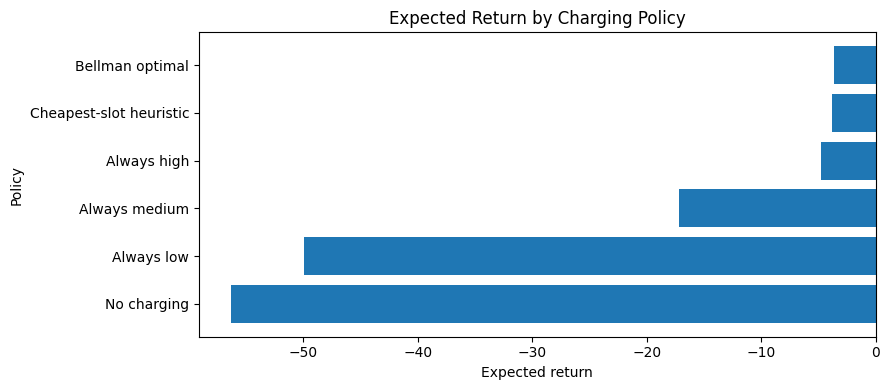

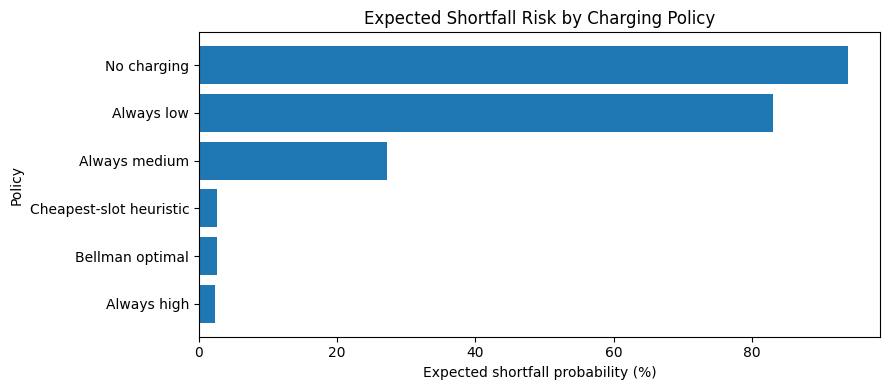

In [22]:
plot_data = final_comparison.sort_values("expected_return", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_data["policy"], plot_data["expected_return"])
ax.set_title("Expected Return by Charging Policy")
ax.set_xlabel("Expected return")
ax.set_ylabel("Policy")
plt.tight_layout()
plt.show()


risk_data = final_comparison.sort_values("expected_shortfall_probability", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(risk_data["policy"], risk_data["expected_shortfall_probability"] * 100)
ax.set_title("Expected Shortfall Risk by Charging Policy")
ax.set_xlabel("Expected shortfall probability (%)")
ax.set_ylabel("Policy")
plt.tight_layout()
plt.show()

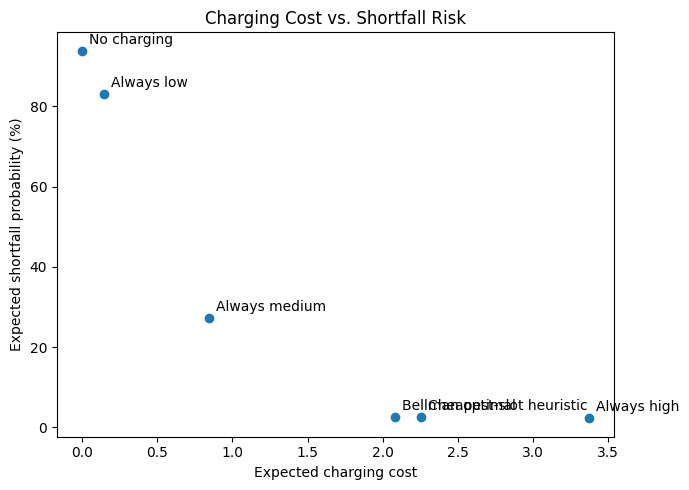

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    final_comparison["expected_cost"],
    final_comparison["expected_shortfall_probability"] * 100
)

for _, row in final_comparison.iterrows():
    ax.annotate(
        row["policy"],
        (row["expected_cost"], row["expected_shortfall_probability"] * 100),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left"
    )

ax.set_title("Charging Cost vs. Shortfall Risk")
ax.set_xlabel("Expected charging cost")
ax.set_ylabel("Expected shortfall probability (%)")
plt.tight_layout()
plt.show()

In [24]:
example_env = ChargingEnv(PARAMS, seed=2026)
state = example_env.reset()
done = False
total_reward = 0.0

while not done:
    action = optimal_action(state)
    state, reward, done, info = example_env.step(action)
    total_reward += reward

trajectory = pd.DataFrame(example_env.trajectory)
last_step = trajectory.iloc[-1]

print(f"Total reward: {total_reward:.4f}")
print(f"Total charging cost: {example_env.total_cost:.4f}")
print(f"Demand: {last_step['demand']:.2f} kWh")
print(f"Final SoC: {last_step['soc_after']:.2f} kWh")
print(f"Shortfall: {bool(last_step['shortfall'])}")

trajectory

Total reward: -2.0816
Total charging cost: 2.0816
Demand: 12.65 kWh
Final SoC: 40.75 kWh
Shortfall: False


,slot,time_label,action,power_kw,soc_before,soc_after,slot_cost,demand,shortfall
0,0,14:00,3,22,5.00,10.50,0.216675,NaN,False
1,1,14:15,3,22,10.50,16.00,0.333841,NaN,False
2,2,14:30,3,22,16.00,21.50,0.390818,NaN,False
3,3,14:45,3,22,21.50,27.00,0.406066,NaN,False
4,4,15:00,3,22,27.00,32.50,0.304148,NaN,False
5,5,15:15,2,11,32.50,35.25,0.114638,NaN,False
6,6,15:30,2,11,35.25,38.00,0.143097,NaN,False
7,7,15:45,2,11,38.00,40.75,0.172358,12.645719,False


### Interpretation

The Bellman-optimal policy provides the best trade-off between charging cost and shortfall risk. It does not simply charge at maximum power in every slot, because high charging power is disproportionately expensive. At the same time, it charges more aggressively than low-cost naive policies, because the terminal penalty for insufficient battery is high.

The evaluation confirms that the policy keeps the probability of running out of energy low while avoiding unnecessary charging costs. This demonstrates the core reinforcement learning trade-off in the smart-charging problem: the agent must balance immediate charging costs against uncertain future energy demand.

## 4.6 Sensitivity and Discussion

Show that the result is robust and translate it into advice, with a few targeted experiments rather than an exhaustive grid. This subsection has to cover:

- Vary the electricity price profile from flat to steeply peaked and show how charging concentrates into the cheap slots as the profile steepens.
- Vary the demand uncertainty `sigma` and show that the policy keeps a larger safety buffer as uncertainty grows, making the safety-versus-cost trade-off explicit.
- Briefly vary the penalty `P` and the maximum power to confirm the policy still reacts sensibly.
- Interpret in plain terms what the agent has learned, then connect it to the business question of Section 5: when home charging is sufficient, and what this implies for the choice between private and public charging infrastructure.

Close by stating the limitations honestly (a single vehicle, a synthetic demand, a stylised price profile), so the scope of the conclusion is clear and not overstated.